# Cambridge Open Data Portal – Metadata Health EDA
**SPARK – CDS – DD4G | Spring 2026**

This notebook performs exploratory data analysis on the Socrata API metadata for the City of Cambridge Open Data Portal, addressing all five base questions:

1. Missing key metadata fields (description, tags, license, department)
2. Datasets overdue per their update schedule
3. Duplicate, inconsistent, or sparse tags
4. Missing or inconsistent license information
5. Initial flagging for LLM-based deeper analysis

## 0. Setup & Data Loading

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime, timezone
import ast, re, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# ── Load data ──────────────────────────────────────────────────────────────────
# The file is in the same folder as this notebook
df = pd.read_csv('/Users/shravani/cambridge_health_dashboard/datasets.csv')
print(f'Shape: {df.shape}')
print(df.dtypes)
df.head(3)

Shape: (282, 13)
id                 object
name               object
description        object
department         object
type               object
createdAt          object
updatedAt          object
dataUpdatedAt      object
tags               object
category           object
license            object
updateFrequency    object
pageViewsTotal      int64
dtype: object


,id,name,description,department,type,createdAt,updatedAt,dataUpdatedAt,tags,category,license,updateFrequency,pageViewsTotal
0,inw8-ircw,COVID-19 Cases in Cambridge (Historical),This dataset is no longer being updated as of ...,Cambridge Department of Public Health,dataset,2020-04-01T21:55:07.000Z,2024-04-18T20:25:49.000Z,2020-12-07T21:06:38.000Z,"['health and safety', 'covid-19']",Public Health,Open Data Commons Public Domain Dedication and...,Historical Data,409986
1,ixg8-tyau,Budget - Salaries,Budgeted Salaries by Position,NaN,dataset,2015-05-27T19:54:14.000Z,2025-04-30T20:11:01.000Z,2025-04-30T20:11:01.000Z,"['fiscal year', 'government and finance', 'bud...",Budget/Finance,Open Data Commons Public Domain Dedication and...,Annually,52749
2,xuad-73uj,Crime Reports,List of crime incidents featured in the Cambri...,City of Cambridge Police Department,dataset,2014-05-30T14:33:29.000Z,2026-02-15T05:04:45.000Z,2026-02-15T05:04:45.000Z,"['health and safety', 'crime', 'police']",Public Safety,Open Data Commons Public Domain Dedication and...,Monthly,24192


In [5]:
pip install openpyxl


Note: you may need to restart the kernel to use updated packages.


In [6]:
# ── Normalise column names ─────────────────────────────────────────────────────
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns.tolist())

['id', 'name', 'description', 'department', 'type', 'createdat', 'updatedat', 'dataupdatedat', 'tags', 'category', 'license', 'updatefrequency', 'pageviewstotal']


In [7]:
# ── Parse datetime columns ─────────────────────────────────────────────────────
date_cols = ['createdat', 'updatedat', 'dataupdatedat']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], utc=True, errors='coerce')

# ── Parse tags column (stored as string representation of list) ────────────────
def parse_tags(val):
    if pd.isna(val) or str(val).strip() in ('', '[]', 'nan'):
        return []
    try:
        parsed = ast.literal_eval(str(val))
        return parsed if isinstance(parsed, list) else [str(parsed)]
    except Exception:
        return [t.strip() for t in str(val).split(',') if t.strip()]

df['tags_list'] = df['tags'].apply(parse_tags)
df['tag_count'] = df['tags_list'].apply(len)

print(df[['tags', 'tag_count']].head(5))

                                                tags  tag_count
0                  ['health and safety', 'covid-19']          2
1  ['fiscal year', 'government and finance', 'bud...          3
2           ['health and safety', 'crime', 'police']          3
3  ['crash', 'motor vehicles', 'transportation', ...          6
4  ['vision zero', 'kendall square', 'eco-totem',...          6


## 1. Missing Key Metadata Fields
> **Base Question 1:** Which datasets are missing description, tags, license, or department?

In [8]:
# ── Define missing logic ───────────────────────────────────────────────────────
def is_missing_text(val):
    if pd.isna(val): return True
    return str(val).strip() == ''

key_fields = ['description', 'tags', 'license', 'department', 'category']
for f in key_fields:
    if f in df.columns:
        if f == 'tags':
            df[f'missing_{f}'] = df['tag_count'] == 0
        else:
            df[f'missing_{f}'] = df[f].apply(is_missing_text)

# Count missing per field
missing_counts = {f: df[f'missing_{f}'].sum() for f in key_fields if f'missing_{f}' in df.columns}
missing_pct    = {f: round(v / len(df) * 100, 1) for f, v in missing_counts.items()}

missing_df = pd.DataFrame({'field': list(missing_counts.keys()),
                            'count': list(missing_counts.values()),
                            'pct':   list(missing_pct.values())})
print(missing_df.sort_values('count', ascending=False).to_string(index=False))

      field  count  pct
    license     74 26.2
 department     56 19.9
   category     14  5.0
       tags      7  2.5
description      1  0.4


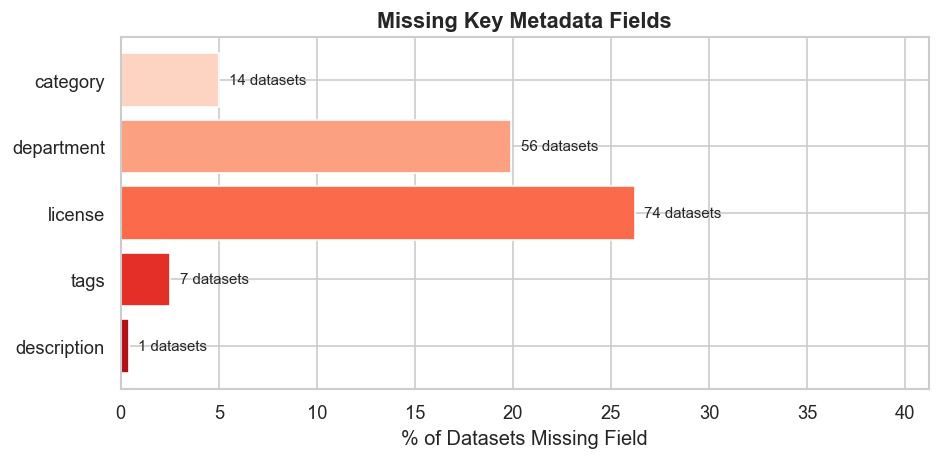

Saved viz1_missing_fields.png


In [9]:
# ── Visualisation 1: Horizontal bar – missing fields ──────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
colors = sns.color_palette('Reds_r', len(missing_df))
bars = ax.barh(missing_df['field'], missing_df['pct'], color=colors)
for bar, cnt in zip(bars, missing_df['count']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{cnt} datasets', va='center', fontsize=9)
ax.set_xlabel('% of Datasets Missing Field')
ax.set_title('Missing Key Metadata Fields', fontsize=13, fontweight='bold')
ax.set_xlim(0, max(missing_df['pct']) + 15)
plt.tight_layout()
plt.savefig('viz1_missing_fields.png')
plt.show()
print('Saved viz1_missing_fields.png')

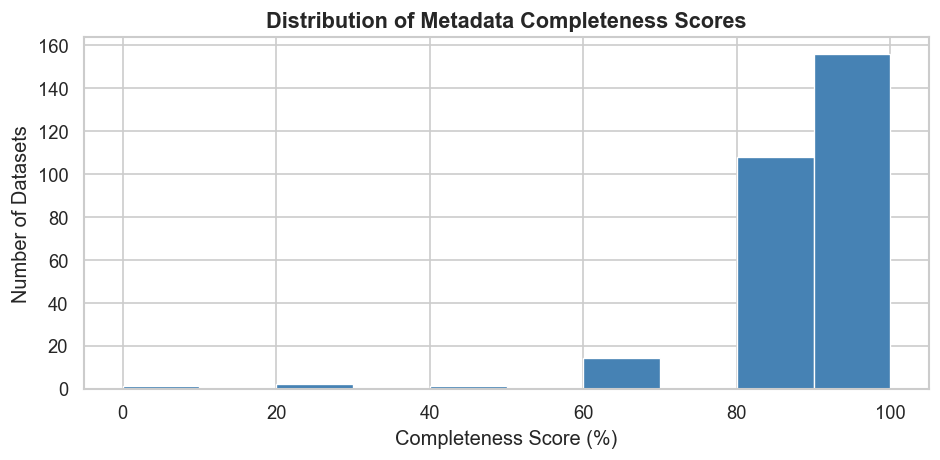

count    282.000000
mean      89.219858
std       14.518165
min        0.000000
25%       80.000000
50%      100.000000
75%      100.000000
max      100.000000
Name: completeness_score, dtype: float64


In [10]:
# ── Metadata completeness score per dataset ───────────────────────────────────
score_cols = [f'missing_{f}' for f in key_fields if f'missing_{f}' in df.columns]
df['missing_count'] = df[score_cols].sum(axis=1)
df['completeness_score'] = round((1 - df['missing_count'] / len(score_cols)) * 100, 1)

# ── Visualisation 2: Distribution of completeness scores ──────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['completeness_score'], bins=10, color='steelblue', edgecolor='white', linewidth=0.8)
ax.set_xlabel('Completeness Score (%)')
ax.set_ylabel('Number of Datasets')
ax.set_title('Distribution of Metadata Completeness Scores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz2_completeness_dist.png')
plt.show()

print(df['completeness_score'].describe())

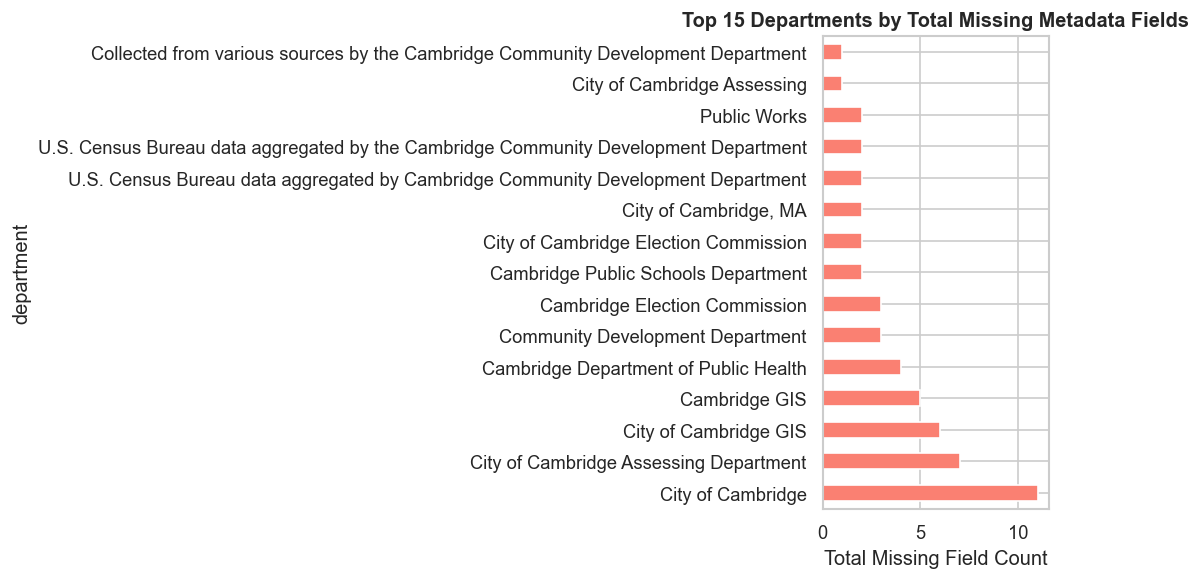

In [11]:
# ── Missing fields by department ──────────────────────────────────────────────
dept_missing = df.groupby('department')[score_cols].sum().sum(axis=1).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(9, 5))
dept_missing.plot(kind='barh', ax=ax, color='salmon')
ax.set_xlabel('Total Missing Field Count')
ax.set_title('Top 15 Departments by Total Missing Metadata Fields', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('viz2b_dept_missing.png')
plt.show()

In [12]:
# ── Flag and display worst offenders ──────────────────────────────────────────
flagged_missing = df[df['missing_count'] >= 2][['name','department','missing_count','completeness_score'] + score_cols].sort_values('missing_count', ascending=False)
print(f'Datasets missing ≥2 key fields: {len(flagged_missing)}')
flagged_missing.head(20)

Datasets missing ≥2 key fields: 18


,name,department,missing_count,completeness_score,missing_description,missing_tags,missing_license,missing_department,missing_category
190,Home Page Featured Story,NaN,5,0.0,True,True,True,True,True
279,Chargepoint - station locations,NaN,4,20.0,False,True,True,True,True
230,Python ETL Update Test Dataset,NaN,4,20.0,False,True,True,True,True
271,Chargepoint - aggregated data,NaN,3,40.0,False,False,True,True,True
52,Cambridge Public School Department Salaries - ...,Cambridge Public Schools Department,2,60.0,False,False,True,False,True
269,DogLicenseInternal,NaN,2,60.0,False,False,True,True,False
221,Bid List: Construction (Historical),NaN,2,60.0,False,True,False,True,False
188,Bid List (Historical),NaN,2,60.0,False,True,False,True,False
181,COVID-19 University Case Counts 5/11/2023,Cambridge Department of Public Health,2,60.0,False,False,True,False,True
4,Eco-Totem Broadway Bicycle Count,NaN,2,60.0,False,False,True,True,False


## 2. Update Schedule Freshness Check
> **Base Question 2:** Which datasets have not been updated within their expected update schedule?

In [13]:
# ── Socrata updateFrequency -> days mapping ────────────────────────────────────
FREQ_DAYS = {
    'Daily': 1, 'daily': 1,
    'Weekly': 7, 'weekly': 7,
    'Biweekly': 14, 'biweekly': 14,
    'Monthly': 30, 'monthly': 30,
    'Quarterly': 91, 'quarterly': 91,
    'Annually': 365, 'annually': 365, 'Annual': 365, 'annual': 365,
    'Hourly': 1, 'hourly': 1,
    'As Needed': None, 'as_needed': None, 'Not Planned': None, 'Historical': None,
    'Irregular': None, 'irregular': None,
}

def get_freq_days(val):
    if pd.isna(val) or str(val).strip() == '':
        return None
    return FREQ_DAYS.get(str(val).strip(), None)

df['freq_days'] = df['updatefrequency'].apply(get_freq_days) if 'updatefrequency' in df.columns else None

# ── Compute days since last data update ───────────────────────────────────────
now = datetime.now(timezone.utc)
update_col = 'dataupdatedat' if 'dataupdatedat' in df.columns else 'updatedat'
df['days_since_update'] = (now - df[update_col]).dt.days

# ── Flag overdue ──────────────────────────────────────────────────────────────
def is_overdue(row):
    if pd.isna(row['freq_days']) or row['freq_days'] is None:
        return False
    if pd.isna(row['days_since_update']):
        return False
    return row['days_since_update'] > row['freq_days'] * 1.5  # 50% grace period

df['is_overdue'] = df.apply(is_overdue, axis=1)
df['overdue_by_days'] = df.apply(
    lambda r: r['days_since_update'] - r['freq_days'] if (r['is_overdue'] and not pd.isna(r['freq_days'])) else np.nan, axis=1)

print(f"Datasets with known update frequency: {df['freq_days'].notna().sum()}")
print(f"Overdue datasets: {df['is_overdue'].sum()}")
df['updatefrequency'].value_counts(dropna=False)

Datasets with known update frequency: 131
Overdue datasets: 2


updatefrequency
As Needed          76
Historical Data    70
Weekly             53
Annually           44
Monthly            15
Daily              12
Quarterly           7
Semiannually        4
NaN                 1
Name: count, dtype: int64

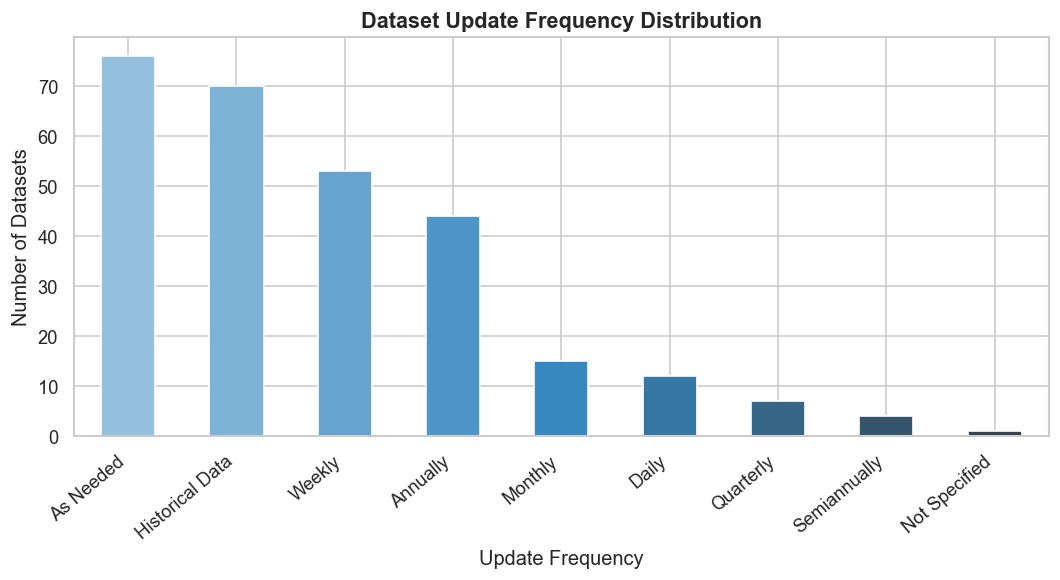

In [14]:
# ── Visualisation 3: Update frequency distribution ────────────────────────────
freq_counts = df['updatefrequency'].value_counts(dropna=False).rename(index={np.nan: 'Not Specified', None: 'Not Specified'})
fig, ax = plt.subplots(figsize=(9, 5))
freq_counts.plot(kind='bar', ax=ax, color=sns.color_palette('Blues_d', len(freq_counts)))
ax.set_xlabel('Update Frequency')
ax.set_ylabel('Number of Datasets')
ax.set_title('Dataset Update Frequency Distribution', fontsize=13, fontweight='bold')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('viz3_update_freq.png')
plt.show()

In [15]:
# ── Staleness: datasets with no update in >2 years regardless of frequency ─────
df['stale_2yr'] = df['days_since_update'] > 730
print(f"Datasets not updated in >2 years: {df['stale_2yr'].sum()}")
df[df['stale_2yr']][['name','department','updatefrequency','days_since_update']].sort_values('days_since_update', ascending=False).head(20)

Datasets not updated in >2 years: 86


,name,department,updatefrequency,days_since_update
248,TRAFFIC_MunicipalParkingLots,City of Cambridge GIS,As Needed,4308
241,PUBLICSAFETY_FireStations,City of Cambridge GIS,As Needed,4308
231,LANDMARK_MunicipalBuildings,City of Cambridge GIS,As Needed,4308
42,Owner Mailing Addresses and Parcel Location Ad...,City of Cambridge Assessing,Historical Data,4169
143,"State and Presidential Elections - November 6,...",Cambridge Election Commission,Historical Data,4121
148,"Voter Turnout - November 6, 2012",Cambridge Election Commission,Historical Data,4121
256,PUBLICSAFETY_PoliceCarRoutes,City of Cambridge,As Needed,3990
237,PUBLICSAFETY_PoliceSectors,City of Cambridge,As Needed,3990
234,PUBLICSAFETY_PoliceResponseDistricts,City of Cambridge,As Needed,3990
260,PUBLICSAFETY_PoliceStation,City of Cambridge,As Needed,3990


In [38]:
# ── Per-dataset overdue check ──────────────────────────────────────────────────
FREQ_DAYS = {
    'Daily': 1, 'Weekly': 7, 'Biweekly': 14,
    'Monthly': 30, 'Quarterly': 90,
    'Semiannually': 180, 'Annually': 365
}

df['allowed_days'] = df['updatefrequency'].apply(
    lambda x: FREQ_DAYS.get(str(x).strip(), None) if pd.notna(x) else None
)

df['is_overdue'] = df.apply(
    lambda row: row['days_since_update'] > row['allowed_days']
    if row['allowed_days'] is not None else False, axis=1
)

df['overdue_by_days'] = df.apply(
    lambda row: max(0, row['days_since_update'] - row['allowed_days'])
    if row['allowed_days'] is not None else 0, axis=1
)

print(f"Overdue datasets: {df['is_overdue'].sum()}")
print(df[df['is_overdue']][['name','updatefrequency','days_since_update','overdue_by_days']].head(10))

Overdue datasets: 3
                                    name updatefrequency  days_since_update  \
25                      Daily Police Log           Daily                  3   
100  Housing Foreclosures 2003 - present        Annually                685   
161      Fresh Pond Reservation Usership        Annually                416   

     overdue_by_days  
25               2.0  
100            320.0  
161             51.0  


## 3. Tag Quality Analysis
> **Base Question 3:** Duplicate, inconsistent, or suspiciously sparse tags?

In [19]:
# ── Tag count distribution ─────────────────────────────────────────────────────
print(df['tag_count'].describe())
print(f"\nDatasets with 0 tags : {(df['tag_count'] == 0).sum()}")
print(f"Datasets with 1-2 tags (sparse): {((df['tag_count'] > 0) & (df['tag_count'] < 3)).sum()}")
print(f"Datasets with ≥3 tags : {(df['tag_count'] >= 3).sum()}")

df['tags_list'] = df['tags'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else (x if isinstance(x, list) else [])
)
df['tag_count'] = df['tags_list'].apply(len)

count    282.000000
mean       2.989362
std        1.498479
min        0.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        9.000000
Name: tag_count, dtype: float64

Datasets with 0 tags : 7
Datasets with 1-2 tags (sparse): 102
Datasets with ≥3 tags : 173


In [39]:
# ── Tag singleton and duplicate detection ─────────────────────────────────────
from collections import Counter

df['tags_list'] = df['tags'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else (x if isinstance(x, list) else [])
)

all_tags = [t.strip().lower() for tags in df['tags_list'] for t in tags]
tag_freq = Counter(all_tags)

# Singleton tags
def has_only_singletons(tags):
    if not tags: return False
    return all(tag_freq.get(t.strip().lower(), 0) == 1 for t in tags)

df['only_singleton_tags'] = df['tags_list'].apply(has_only_singletons)
print(f"Datasets with only singleton tags: {df['only_singleton_tags'].sum()}")

# Near duplicate tags
import re
norm = lambda s: re.sub(r'[^a-z0-9]', '', s.lower())
unique_tags = list(tag_freq.keys())
norm_groups = {}
for t in unique_tags:
    key = norm(t)
    norm_groups.setdefault(key, []).append(t)

dup_groups = {k: v for k, v in norm_groups.items() if len(v) > 1}
print(f"Tag groups with potential duplicates: {len(dup_groups)}")
for k, v in list(dup_groups.items())[:10]:
    print(f"  {v}")


Datasets with only singleton tags: 3
Tag groups with potential duplicates: 0


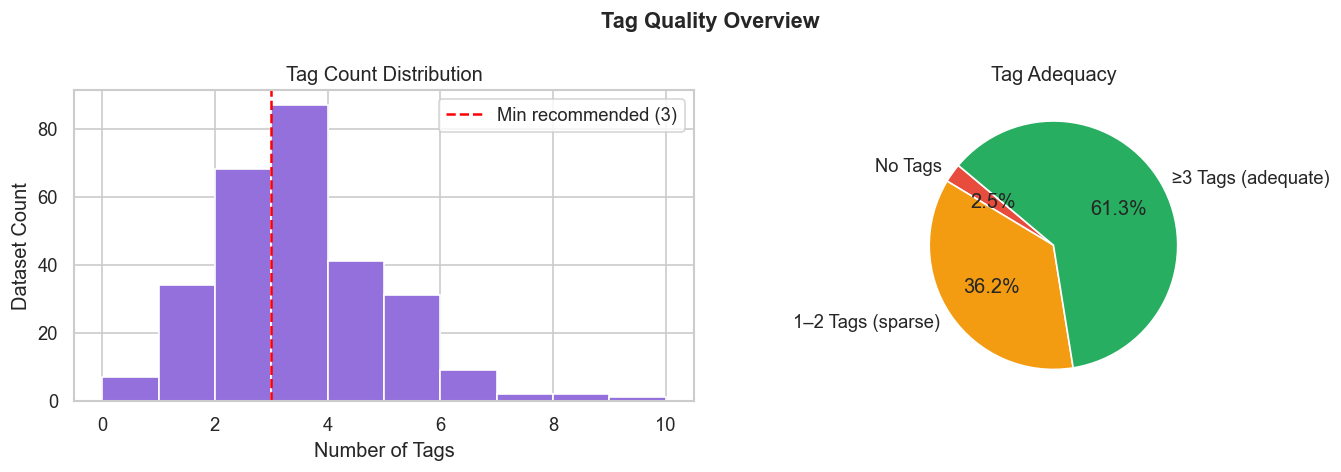

In [20]:
# ── Visualisation 5: Tag count distribution ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df['tag_count'], bins=range(0, df['tag_count'].max()+2), color='mediumpurple', edgecolor='white')
axes[0].axvline(3, color='red', linestyle='--', label='Min recommended (3)')
axes[0].set_xlabel('Number of Tags')
axes[0].set_ylabel('Dataset Count')
axes[0].set_title('Tag Count Distribution')
axes[0].legend()

# Pie: sparse vs adequate vs no tags
zero   = (df['tag_count'] == 0).sum()
sparse = ((df['tag_count'] > 0) & (df['tag_count'] < 3)).sum()
ok     = (df['tag_count'] >= 3).sum()
axes[1].pie([zero, sparse, ok], labels=['No Tags', '1–2 Tags (sparse)', '≥3 Tags (adequate)'],
            colors=['#e74c3c','#f39c12','#27ae60'], autopct='%1.1f%%', startangle=140)
axes[1].set_title('Tag Adequacy')

plt.suptitle('Tag Quality Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz5_tag_quality.png')
plt.show()

In [23]:
print(df['tag_count'].describe())
print(f"\nDatasets with 0 tags: {(df['tag_count'] == 0).sum()}")
print(f"Datasets with 1-2 tags (sparse): {((df['tag_count'] > 0) & (df['tag_count'] < 3)).sum()}")

print(f"Datasets with >=3 tags: {(df['tag_count'] >= 3).sum()}")

count    282.000000
mean       2.989362
std        1.498479
min        0.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        9.000000
Name: tag_count, dtype: float64

Datasets with 0 tags: 7
Datasets with 1-2 tags (sparse): 102
Datasets with >=3 tags: 173


## 4. License Analysis
> **Base Question 4:** Missing or inconsistent license information?

In [24]:
# ── License value counts ───────────────────────────────────────────────────────
lic_col = 'license'
df['license_clean'] = df[lic_col].fillna('').str.strip()
df['missing_license'] = df['license_clean'] == ''

lic_counts = df['license_clean'].replace('', 'MISSING').value_counts()
print(lic_counts)

license_clean
Open Data Commons Public Domain Dedication and License    206
MISSING                                                    74
Public Domain U.S. Government                               1
Public Domain                                               1
Name: count, dtype: int64


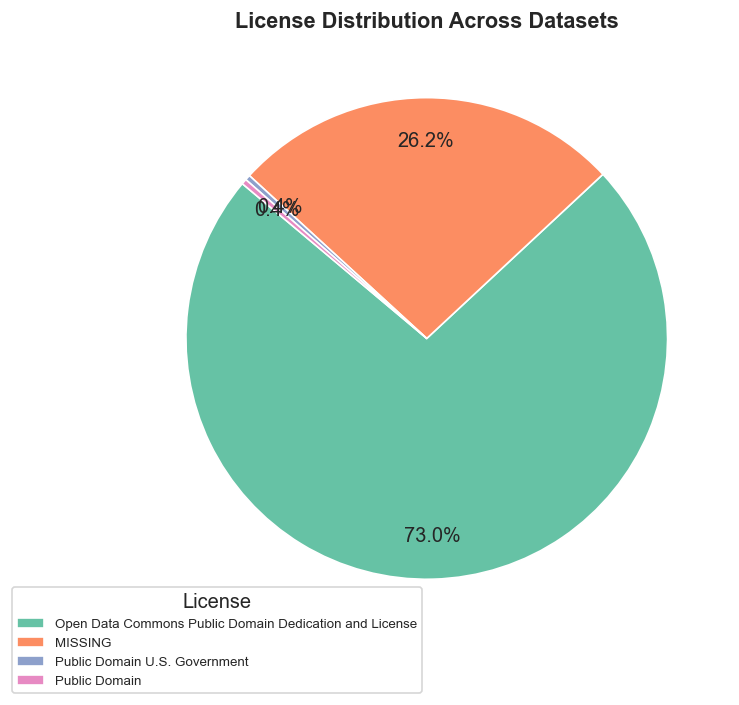


Datasets missing license: 74 (26.2%)


In [44]:
fig, ax = plt.subplots(figsize=(9, 6))
colors_lic = sns.color_palette('Set2', len(lic_counts))
wedges, texts, autotexts = ax.pie(
lic_counts.values, labels=None,
colors=colors_lic, autopct='%1.1f%%', startangle=140, pctdistance=0.82)
ax.legend(wedges, lic_counts.index, title='License', loc='lower left',
bbox_to_anchor=(-0.2, -0.1), fontsize=8)
ax.set_title('License Distribution Across Datasets', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz6_license_dist.png')
plt.show()
print(f"\nDatasets missing license: {df['missing_license'].sum()} ({df['missing_license'].mean()*100:.1f}%)")

In [26]:
# ── License inconsistency by department ───────────────────────────────────────
lic_dept = df.groupby('department')['license_clean'].agg(
    n_datasets='count',
    n_missing=lambda x: (x == '').sum(),
    n_unique=lambda x: x.replace('', np.nan).nunique()
).reset_index()

# Departments with both missing AND present licenses → inconsistent
lic_dept['inconsistent'] = (lic_dept['n_missing'] > 0) & (lic_dept['n_missing'] < lic_dept['n_datasets'])
print('Departments with inconsistent licensing:')
lic_dept[lic_dept['inconsistent']].sort_values('n_datasets', ascending=False)

Departments with inconsistent licensing:


,department,n_datasets,n_missing,n_unique,inconsistent
13,Cambridge GIS,35,5,1,True
25,City of Cambridge,22,11,1,True
32,City of Cambridge Community Development Depart...,11,1,1,True
10,Cambridge Department of Public Health,10,2,1,True
62,Public Works,9,2,1,True
34,City of Cambridge GIS,8,6,1,True
4,Cambridge Community Development Department,6,1,1,True
48,Community Development Department,6,3,1,True
33,City of Cambridge Election Commission,3,1,1,True
44,"City of Cambridge, MA",3,2,1,True


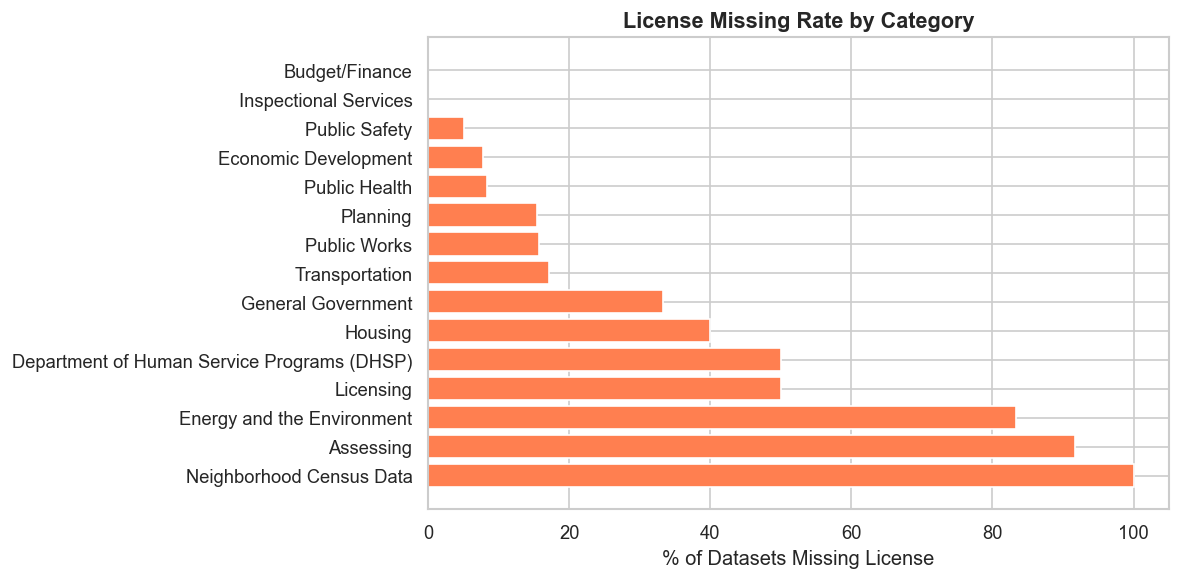

In [27]:
# ── Visualisation 7: License missing rate by category ─────────────────────────
if 'category' in df.columns:
    lic_cat = df.groupby('category')['missing_license'].agg(['sum','count']).reset_index()
    lic_cat.columns = ['category','missing','total']
    lic_cat['pct_missing'] = lic_cat['missing'] / lic_cat['total'] * 100
    lic_cat = lic_cat.sort_values('pct_missing', ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(lic_cat['category'], lic_cat['pct_missing'], color='coral')
    ax.set_xlabel('% of Datasets Missing License')
    ax.set_title('License Missing Rate by Category', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('viz7_license_by_category.png')
    plt.show()

## 5. Overall Health Score & Flagging for LLM Analysis
> **Base Question 5:** Datasets that appear healthy on basic checks but may have deeper issues.

In [37]:
# ── Build composite health score (0–100) ──────────────────────────────────────
# Components: completeness (40%), freshness (30%), tag quality (15%), license (15%)

# Freshness score: 100 if up to date, 0 if overdue, scaled if no freq defined
# # def freshness_score(row):
#     if pd.isna(row['days_since_update']): return 50  # unknown
#     if row['is_overdue']: return max(0, 100 - int(row['overdue_by_days'] / 30) * 10)
#     if row['days_since_update'] > 730: return 20     # stale >2 yrs
#     return 100

# df['freshness_score'] = df.apply(freshness_score, axis=1)

# # Tag score
# def tag_score(row):
#     if row['tag_count'] == 0: return 0
#     if row['tag_count'] < 3:  return 50
#     if row['only_singleton_tags']: return 60
#     return 100

# df['tag_score'] = df.apply(tag_score, axis=1)

# # License score
# df['license_score'] = (~df['missing_license']).astype(int) * 100

# # Composite
# df['health_score'] = (
#     df['completeness_score'] * 0.40 +
#     df['freshness_score']    * 0.30 +
#     df['tag_score']          * 0.15 +
#     df['license_score']      * 0.15
# ).round(1)


In [30]:
# # ── Visualisation 8: Overall health score distribution ────────────────────────
# bins = [0, 40, 60, 80, 100]
# labels = ['Critical (<40)', 'Poor (40–60)', 'Fair (60–80)', 'Good (80–100)']
# df['health_band'] = pd.cut(df['health_score'], bins=bins, labels=labels, include_lowest=True)

# band_counts = df['health_band'].value_counts().reindex(labels)
# pal = ['#e74c3c','#e67e22','#f1c40f','#2ecc71']

# fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# # Bar
# band_counts.plot(kind='bar', ax=axes[0], color=pal, edgecolor='white')
# axes[0].set_xlabel('Health Band')
# axes[0].set_ylabel('Number of Datasets')
# axes[0].set_title('Dataset Health Band Distribution')
# axes[0].tick_params(axis='x', rotation=20)
# for bar, cnt in zip(axes[0].patches, band_counts):
#     axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(cnt), ha='center', fontsize=10)

# # Histogram
# axes[1].hist(df['health_score'], bins=20, color='steelblue', edgecolor='white')
# axes[1].axvline(df['health_score'].mean(), color='red', linestyle='--', label=f"Mean = {df['health_score'].mean():.1f}")
# axes[1].set_xlabel('Health Score (0–100)')
# axes[1].set_ylabel('Count')
# axes[1].set_title('Health Score Distribution')
# axes[1].legend()

# plt.suptitle('Overall Metadata Health Score', fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.savefig('viz8_health_score.png')
# plt.show()

In [31]:
# # ── Datasets that pass basic checks but have surface-level description issues ──
# # Proxy for "appears healthy but suspect": high completeness yet very short description

# df['desc_len'] = df['description'].fillna('').str.split().str.len()
# df['short_desc'] = (df['desc_len'] > 0) & (df['desc_len'] < 15)  # non-empty but very short

# # Flag: completeness>=80 but short description (passes field-existence check, fails quality)
# df['superficially_healthy'] = (df['completeness_score'] >= 80) & df['short_desc']
# print(f"Datasets superficially healthy but with very short description: {df['superficially_healthy'].sum()}")
# df[df['superficially_healthy']][['name','department','desc_len','completeness_score','health_score']].sort_values('desc_len')

In [34]:
# # ── Visualisation 9: Heatmap of flag co-occurrence by category ─────────────────
# flag_cols = ['missing_description','missing_tags','missing_license','missing_department',
#              'is_overdue','has_sparse_tags','superficially_healthy']
# flag_cols_present = [c for c in flag_cols if c in df.columns]

# if 'category' in df.columns:
#     heatmap_data = df.groupby('category')[flag_cols_present].mean().mul(100).round(1)
#     fig, ax = plt.subplots(figsize=(12, 7))
#     sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5,
#                 ax=ax, cbar_kws={'label': '% of datasets flagged'})
#     ax.set_title('Flag Rate (%) by Category', fontsize=13, fontweight='bold')
#     ax.set_xlabel('')
#     ax.set_ylabel('')
#     plt.xticks(rotation=35, ha='right')
#     plt.tight_layout()
#     plt.savefig('viz9_flag_heatmap.png')
#     plt.show()

## 6. Export Flagged Datasets

In [33]:
# # ── Build master flagged summary ───────────────────────────────────────────────
# output_cols = [
#     'id','name','department','category',
#     'missing_description','missing_tags','missing_license','missing_department',
#     'tag_count','has_sparse_tags','only_singleton_tags',
#     'updatefrequency','days_since_update','is_overdue','overdue_by_days','stale_2yr',
#     'license_clean','missing_license',
#     'desc_len','short_desc','superficially_healthy',
#     'completeness_score','freshness_score','tag_score','license_score','health_score','health_band'
# ]
# output_cols_present = [c for c in output_cols if c in df.columns]

# df_out = df[output_cols_present].sort_values('health_score')
# df_out.to_csv('cambridge_metadata_health_flags.csv', index=False)
# print(f'Exported {len(df_out)} rows to cambridge_metadata_health_flags.csv')
# df_out.head(10)

In [32]:
# # ── Print summary statistics for final report ──────────────────────────────────
# total = len(df)
# print('='*60)
# print(f' METADATA HEALTH SUMMARY – Cambridge Open Data Portal')
# print('='*60)
# print(f'Total datasets analysed          : {total}')
# print(f'Missing description              : {df["missing_description"].sum()} ({df["missing_description"].mean()*100:.1f}%)')
# print(f'Missing tags (0 tags)            : {df["missing_tags"].sum()} ({df["missing_tags"].mean()*100:.1f}%)')
# print(f'Sparse tags (<3)                 : {df["has_sparse_tags"].sum()} ({df["has_sparse_tags"].mean()*100:.1f}%)')
# print(f'Missing license                  : {df["missing_license"].sum()} ({df["missing_license"].mean()*100:.1f}%)')
# print(f'Missing department               : {df["missing_department"].sum()} ({df["missing_department"].mean()*100:.1f}%)')
# print(f'Overdue (vs. stated schedule)    : {df["is_overdue"].sum()}')
# print(f'Stale (not updated >2 years)     : {df["stale_2yr"].sum()}')
# print(f'Superficially healthy (suspect)  : {df["superficially_healthy"].sum()}')
# print(f'Avg health score                 : {df["health_score"].mean():.1f}/100')
# print(f'Critical health (<40)            : {(df["health_band"]=="Critical (<40)").sum()}')
# print('='*60)